In [1]:
import numpy as np
# ============================================================
# Load SST Data
# ============================================================
data_marine = np.load("east_china_sea_sst.npy")
print(data_marine.shape)

(2989, 5001)


In [2]:
# ---------------------------
# Splits
# ---------------------------
warmup_len = 100
train_len  = 3900
val_len    = 500
test_len   = 500

# ---------------------------
# Normalize
# ---------------------------

# Compute stats 
X_train = data_marine[:, 0:warmup_len + train_len]
mean = X_train.mean(axis=1, keepdims=True)
std  = X_train.std(axis=1, keepdims=True)

# Normalize the data with its own stats
data_norm = (data_marine - mean) / std
np.save(f"sst_normalized_5k.npy", data_norm)
print(f"Saved sst_normalized_5k.npy")
data_norm = data_norm.T

Saved sst_normalized_5k.npy


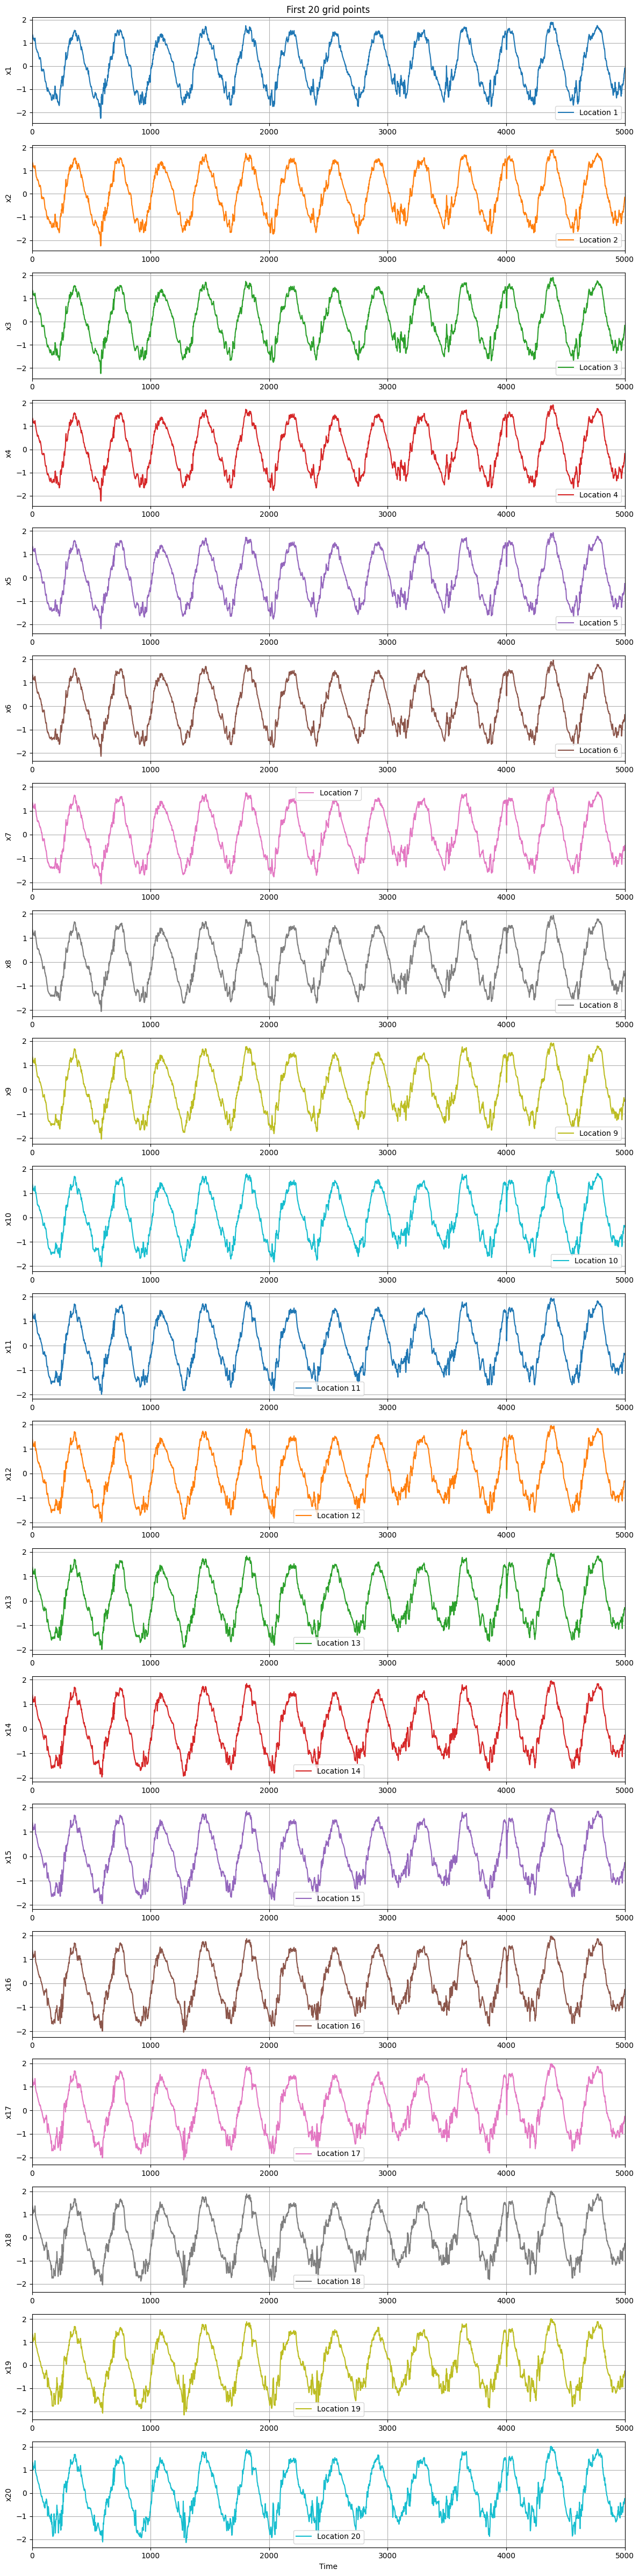

In [3]:
# ============================================================
# Visualization: First 20 grid points
# ============================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 48))
num_vars_to_plot = 20
time = np.arange(data_norm.shape[0])

for i in range(num_vars_to_plot):
    plt.subplot(num_vars_to_plot, 1, i + 1)
    plt.plot(time, data_norm[:, i], label=f'Location {i+1}', color=f'C{i % 10}')
    plt.ylabel(f'x{i+1}')
    plt.grid(True)
    if i == 0:
        plt.title("First 20 grid points")
    if i == num_vars_to_plot - 1:
        plt.xlabel('Time')
    plt.legend()
    plt.xlim(0, 5000)  

plt.tight_layout()
plt.show()